In [33]:
import pandas as pd, numpy as np, statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
#from caas_jupyter_tools import display_dataframe_to_user
from sklearn.metrics import mean_squared_error, r2_score

In [34]:

# EDA from week2 Mod B
df_diabetes = pd.read_csv("diabetes_binary_health_indicators_BRFSS2015.csv")
df_ckd = pd.read_csv("Chronic_Kidney_Dsease_data.csv")
df_hypertension = pd.read_csv("hypertension_dataset.csv")
df_alzheimers = pd.read_csv("alzheimers_disease_data.csv")

# Generate basic summaries
diabetes_desc = df_diabetes.describe(include='all')
ckd_desc = df_ckd.describe(include='all')
hypertension_desc = df_hypertension.describe(include='all')
alzheimers_desc = df_alzheimers.describe(include='all')

# Check for duplicates
diabetes_duplicates = df_diabetes.duplicated().sum()
ckd_duplicates = df_ckd.duplicated().sum()
alzheimers_duplicates = df_alzheimers.duplicated().sum()
_duplicates = df_hypertension.duplicated().sum()
# Check for nulls
diabetes_nulls = df_diabetes.isnull().sum()
ckd_nulls = df_ckd.isnull().sum()
hypertension_nulls = df_hypertension.isnull().sum()
alzheimers__nulls = df_alzheimers.isnull().sum()

# Display descriptive summaries

print("\n===alzheimers-Summary ===")
print(ckd_desc)
# Return duplicates and total null values per dataset
print("\n=== Duplicates in alzheimers_duplicates Dataset ===")
print(f"alzheimers: {alzheimers_duplicates}")

# Return nulls
print("\n=== Total Null Values in alzheimers Dataset ===")
print(f"Diabealzheimerstes: {alzheimers__nulls.sum()}")


#Diabetes Dataset
#Duplicates: 24,206 rows — significant duplication, should be reviewed or removed
#Missing values: None
#Usability: Usable after deduplication

#Chronic Kidney Disease (CKD) Dataset
#Duplicates: None
#Missing values: None\
#Usability: Clean and ready for analysis

#Hypertension Dataset
#Duplicates: None
#Missing values: None
#Usability: Ready to use

# Steps to clean up Diabetes Dataset 
#Remove duplicates from the diabetes dataset: df_diabetes.drop_duplicates(inplace=True)
#Consider class balance checks (e.g., ratio of positive to negative labels)
#Identify categorical features and apply encoding (pd.get_dummies or OrdinalEncoder)
#Explore mode, median, and outliers for inconsistent data (e.g., age = 0)

#1 Remove Duplicates
df_diabetes.drop_duplicates(inplace=True)
#2 Handling any missing values
df_diabetes.fillna(df_diabetes.median(), inplace=True)  # For numeric columns
df_diabetes.fillna("Unknown", inplace=True)    # For categorical columns
#3Check for Inconsistencies
  #Negative ages or values outside expected range
  #Incorrect data types (e.g., numeric coded as string)
#4 Check for Class Imbalance

print(df_diabetes['Diabetes_binary'].value_counts(normalize=True))
print(df_hypertension['Hypertension'].value_counts(normalize=True))
#print(df_ckd['classification'].value_counts(normalize=True)) 

# Encode Categorical Variables
# One-hot encoding (for logistic regression, tree-based models)
df = pd.get_dummies(df_diabetes, drop_first=True)

# Or ordinal encoding if there is a natural order
#print("Arun")
#print(df_ckd.columns)
categorical_cols = df_ckd.select_dtypes(include=['object', 'category']).columns.tolist()
#print("Categorical columns:", categorical_cols)

from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder()
df_ckd[['DoctorInCharge']] = encoder.fit_transform(df_ckd[['DoctorInCharge']])




===alzheimers-Summary ===
          PatientID          Age       Gender   Ethnicity  \
count   1659.000000  1659.000000  1659.000000  1659.00000   
unique          NaN          NaN          NaN         NaN   
top             NaN          NaN          NaN         NaN   
freq            NaN          NaN          NaN         NaN   
mean     830.000000    54.441230     0.515371     0.71308   
std      479.056364    20.549757     0.499914     1.00043   
min        1.000000    20.000000     0.000000     0.00000   
25%      415.500000    36.000000     0.000000     0.00000   
50%      830.000000    54.000000     1.000000     0.00000   
75%     1244.500000    72.000000     1.000000     1.00000   
max     1659.000000    90.000000     1.000000     3.00000   

        SocioeconomicStatus  EducationLevel          BMI      Smoking  \
count           1659.000000     1659.000000  1659.000000  1659.000000   
unique                  NaN             NaN          NaN          NaN   
top                  

In [35]:
TARGET_COLUMN = "MMSE"  

In [36]:
df=df_alzheimers
# Drop obvious ID columns if present (prevents leakage / meaningless signal)
for col in ["PatientID", "patient_id", "ID", "Id"]:
    if col in df.columns:
        df = df.drop(columns=[col])

# Separate X, y
y = df[TARGET_COLUMN]
X = df.drop(columns=[TARGET_COLUMN])

# Identify categorical vs numeric
categorical_cols = [c for c in X.columns if X[c].dtype == "object"]
numeric_cols     = [c for c in X.columns if np.issubdtype(X[c].dtype, np.number)]

print("Categorical cols:", categorical_cols)
print("Numeric cols:", numeric_cols, "\n")



Categorical cols: ['DoctorInCharge']
Numeric cols: ['Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'FunctionalAssessment', 'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion', 'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness', 'Diagnosis'] 



,model,n_features,test_R2,test_RMSE
2,OLS_Backward(p>0.05 drop),5,0.122,7.972
0,OLS_Baseline(All Features),32,0.107,8.039
4,PLSR(n_components=5),5,0.107,8.039
1,OLS_Forward(Top10|corr|),10,0.071,8.200
3,PCR(n_components=1),1,0.029,8.385


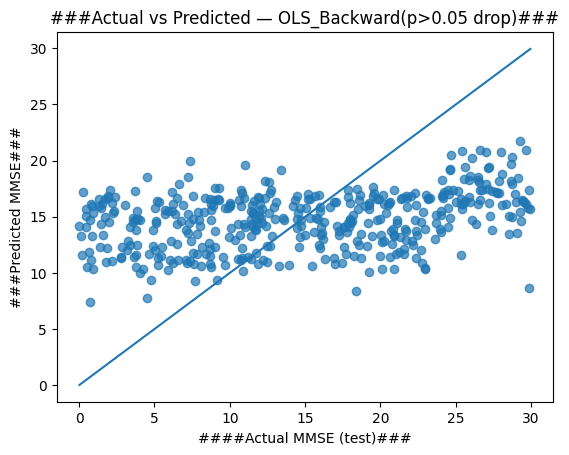

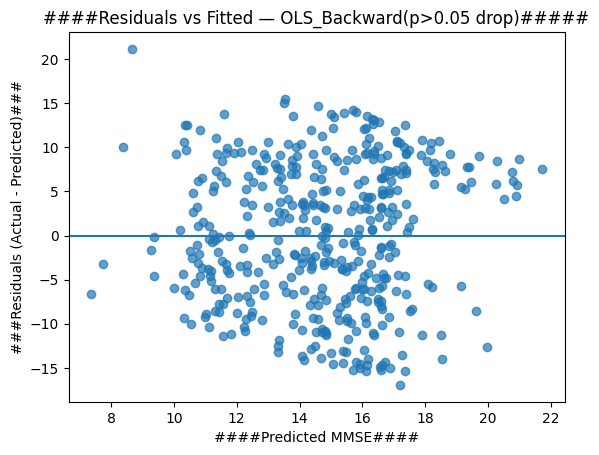

In [40]:
import numpy as np, pandas as pd, statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# --- 1) Clean rebuild of X, y (numeric-only); undo any string-cast of Diagnosis ---
df = df.drop(columns=[c for c in ["PatientID","DoctorInCharge"] if c in df.columns])
if "Diagnosis" in df.columns and df["Diagnosis"].dtype == "object":
    df["Diagnosis"] = pd.to_numeric(df["Diagnosis"], errors="coerce")

y = df["MMSE"].values
X = df.drop(columns=["MMSE"]).select_dtypes(include=[np.number])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---- Helpers (no squared=False) ----
def rmse(y_true, y_pred):
    y_pred = np.asarray(y_pred).ravel()
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def eval_preds(y_true, y_pred):
    y_pred = np.asarray(y_pred).ravel()
    return {"test_R2": r2_score(y_true, y_pred), "test_RMSE": rmse(y_true, y_pred)}

def fit_ols_feats(feats, name):
    Xt_tr = pd.DataFrame(X_train, columns=X.columns)[feats]
    Xt_te = pd.DataFrame(X_test,  columns=X.columns)[feats]
    Xm_tr = sm.add_constant(Xt_tr, has_constant="add")
    Xm_te = sm.add_constant(Xt_te, has_constant="add")
    m = sm.OLS(y_train, Xm_tr).fit()
    pred = m.predict(Xm_te)
    met = {"model": name, "n_features": len(feats), **eval_preds(y_test, pred)}
    return m, met, pred

def backward_elimination_pval(Xdf, yv, alpha_out=0.05, max_steps=40):
    cols = list(Xdf.columns)
    step = 0
    while step < max_steps and len(cols) > 1:
        Xc = sm.add_constant(Xdf[cols], has_constant="add")
        model = sm.OLS(yv, Xc).fit()
        pvals = model.pvalues.drop("const", errors="ignore")
        worst, worst_p = pvals.idxmax(), pvals.max()
        if worst_p > alpha_out:
            cols.remove(worst); step += 1
        else:
            break
    return cols

# 1) Baseline OLS (all numeric features)
all_feats = list(X.columns)
ols_base_model, ols_base_metrics, yhat_ols_base = fit_ols_feats(all_feats, "OLS_Baseline(All Features)")

# 2) Simple forward selection (top-10 by |corr| with target on train set)
corr = pd.DataFrame(X_train, columns=X.columns).assign(MMSE=y_train).corr()["MMSE"].abs().sort_values(ascending=False)
fwd_feats = [c for c in corr.index if c != "MMSE"][:10]
ols_fwd_model, ols_fwd_metrics, yhat_ols_fwd = fit_ols_feats(fwd_feats, "OLS_Forward(Top10|corr|)")

# 3) Backward elimination by p-values (drop worst p>0.05 until stable or max steps)
bwd_feats = backward_elimination_pval(pd.DataFrame(X_train, columns=X.columns), y_train, alpha_out=0.05, max_steps=40)
ols_bwd_model, ols_bwd_metrics, yhat_ols_bwd = fit_ols_feats(bwd_feats, "OLS_Backward(p>0.05 drop)")

# 4) PCR: Standardize -> PCA -> LinearRegression; tune components on simple val split
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=123)
scaler = StandardScaler().fit(X_tr)
X_tr_s  = scaler.transform(X_tr)
X_val_s = scaler.transform(X_val)
X_test_s= scaler.transform(X_test)

best_pcr_n, best_pcr_rmse = None, np.inf
for n in range(1, min(15, X_train.shape[1]) + 1):
    pca = PCA(n_components=n, random_state=42).fit(X_tr_s)
    lr  = LinearRegression().fit(pca.transform(X_tr_s), y_tr)
    y_val_hat = lr.predict(pca.transform(X_val_s))
    this_rmse = rmse(y_val, y_val_hat)  # <-- sqrt(MSE)
    if this_rmse < best_pcr_rmse:
        best_pcr_rmse, best_pcr_n = this_rmse, n

# Refit PCR on full train
scaler_full = StandardScaler().fit(X_train)
Xtr_s = scaler_full.transform(X_train)
Xte_s = scaler_full.transform(X_test)
pca_full = PCA(n_components=best_pcr_n, random_state=42).fit(Xtr_s)
lr_full  = LinearRegression().fit(pca_full.transform(Xtr_s), y_train)
yhat_pcr = lr_full.predict(pca_full.transform(Xte_s))
pcr_metrics = {"model": f"PCR(n_components={best_pcr_n})", "n_features": int(best_pcr_n), **eval_preds(y_test, yhat_pcr)}

# 5) PLSR: tune components on val split (1..10), refit on full train
best_pls_n, best_pls_rmse = None, np.inf
for n in range(1, min(10, X_train.shape[1]) + 1):
    pls = PLSRegression(n_components=n, scale=True).fit(X_tr, y_tr)
    y_val_hat = pls.predict(X_val).ravel()
    this_rmse = rmse(y_val, y_val_hat)  # <-- sqrt(MSE)
    if this_rmse < best_pls_rmse:
        best_pls_rmse, best_pls_n = this_rmse, n

pls_full = PLSRegression(n_components=best_pls_n, scale=True).fit(X_train, y_train)
yhat_pls = pls_full.predict(X_test).ravel()
pls_metrics = {"model": f"PLSR(n_components={best_pls_n})", "n_features": int(best_pls_n), **eval_preds(y_test, yhat_pls)}

# 6) Consolidated metrics and display
metrics_df = pd.DataFrame([ols_base_metrics, ols_fwd_metrics, ols_bwd_metrics, pcr_metrics, pls_metrics])
metrics_df = metrics_df.sort_values("test_RMSE")
try:
        from IPython.display import display
        display(metrics_df.round(3))
except Exception:
        # Fallback 2: plain terminal-friendly print
        with pd.option_context('display.max_columns', None, 'display.width', None):
            print(metrics_df.round(3).to_string(index=False))

# 7) Pick best model for plots
best_name = metrics_df.iloc[0]["model"]
pred_map = {
    "OLS_Baseline(All Features)": yhat_ols_base,
    "OLS_Forward(Top10|corr|)": yhat_ols_fwd,
    "OLS_Backward(p>0.05 drop)": yhat_ols_bwd,
    f"PCR(n_components={best_pcr_n})": yhat_pcr,
    f"PLSR(n_components={best_pls_n})": yhat_pls
}
yhat_best = pred_map[best_name]

# Plot 1: Actual vs Predicted (Test)
plt.figure()
plt.scatter(y_test, yhat_best, alpha=0.7)
mn, mx = float(np.min([y_test.min(), yhat_best.min()])), float(np.max([y_test.max(), yhat_best.max()]))
plt.plot([mn, mx], [mn, mx])
plt.xlabel("####Actual MMSE (test)###")
plt.ylabel("###Predicted MMSE###")
plt.title(f"###Actual vs Predicted — {best_name}###")
plt.show()

# Plot 2: Residuals vs Fitted (Test)
resid = y_test - yhat_best
plt.figure()
plt.scatter(yhat_best, resid, alpha=0.7)
plt.axhline(0)
plt.xlabel("####Predicted MMSE####")
plt.ylabel("###Residuals (Actual - Predicted)###")
plt.title(f"####Residuals vs Fitted — {best_name}#####")
plt.show()

